<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/simulation/vkernel_live_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V-KERNEL LIVE SIMULATION
# simplified Colab version
# candidate field -> interaction -> pruning -> convergence -> Bindu

In [1]:
!pip install numpy matplotlib networkx

import math
import random
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# V-Kernel Live Simulation
This notebook demonstrates a simplified field-based computation model:
candidate generation, interaction, pruning, convergence, and Bindu formation.

In [2]:
SEED = 42
NUM_CANDIDATES = 12
STEPS = 30

NOISE_LEVEL = 0.18
PRUNE_THRESHOLD = 0.10

ALPHA_COHERENCE = 1.0
BETA_SHADOW = 0.8
GAMMA_VITALITY = 0.6

SHOW_EVERY = 5

random.seed(SEED)
np.random.seed(SEED)

## Canonical Field
The system starts from a 19-node geometric lattice with hexagonal / flower topology.

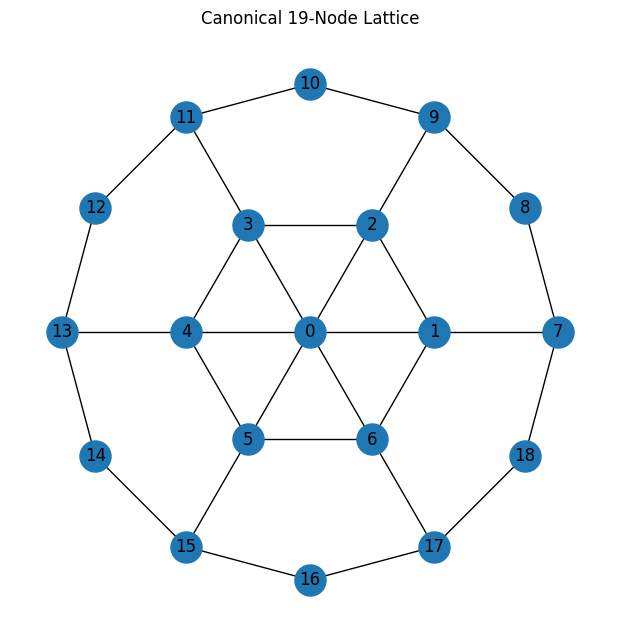

In [3]:
def generate_hex_positions():
    positions = {}
    idx = 0

    positions[idx] = (0.0, 0.0)
    idx += 1

    r1 = 1.0
    for k in range(6):
        angle = 2 * math.pi * k / 6
        positions[idx] = (r1 * math.cos(angle), r1 * math.sin(angle))
        idx += 1

    r2 = 2.0
    for k in range(12):
        angle = 2 * math.pi * k / 12
        positions[idx] = (r2 * math.cos(angle), r2 * math.sin(angle))
        idx += 1

    return positions


def build_graph():
    pos = generate_hex_positions()
    G = nx.Graph()

    for n, p in pos.items():
        G.add_node(n, pos=p)

    nodes = list(G.nodes())
    for i in nodes:
        xi, yi = G.nodes[i]["pos"]
        for j in nodes:
            if i >= j:
                continue
            xj, yj = G.nodes[j]["pos"]
            d = math.dist((xi, yi), (xj, yj))
            if d <= 1.18:
                G.add_edge(i, j, weight=1.0)

    return G


G = build_graph()
pos = nx.get_node_attributes(G, "pos")

plt.figure(figsize=(6, 6))
nx.draw(G, pos, with_labels=True, node_size=500)
plt.title("Canonical 19-Node Lattice")
plt.axis("equal")
plt.show()

## Projections and State
Three projections observe the same field:
- radial
- ring
- node

These are encoded into a unified state representation.

In [4]:
def radial_projection(G, z):
    center = np.array(G.nodes[0]["pos"])
    out = np.zeros(len(G.nodes()), dtype=float)

    for i in G.nodes():
        pi = np.array(G.nodes[i]["pos"])
        ri = np.linalg.norm(pi - center) + 1e-8
        out[i] = abs(z[i]) / ri

    return out


def ring_projection(G, z):
    out = np.zeros(len(G.nodes()), dtype=float)
    center = np.array(G.nodes[0]["pos"])

    for i in G.nodes():
        pi = np.array(G.nodes[i]["pos"])
        r = np.linalg.norm(pi - center)
        if r < 0.5:
            ring_id = 0
        elif r < 1.5:
            ring_id = 1
        else:
            ring_id = 2
        out[i] = abs(z[i]) * (ring_id + 1)

    return out


def node_projection(G, z):
    out = np.zeros(len(G.nodes()), dtype=float)

    for i in G.nodes():
        degree = G.degree(i)
        out[i] = abs(z[i]) * (1.0 + 0.15 * degree)

    return out


def encode_state(radial, ring, node, z):
    mass = float(np.mean(np.abs(z)))
    flow = float(np.mean(radial))
    structure = float(np.std(node))
    balance = float(1.0 / (1.0 + np.std(ring)))
    law = float(np.mean(np.real(z)))
    potential = float(np.max(np.abs(z)))

    return np.array([mass, flow, structure, balance, law, potential], dtype=float)

## Dynamics and Convergence
Candidates evolve through interaction.
Weak states are pruned.
The most coherent candidate dominates over time.

In [5]:
def adjacency_matrix(G):
    A = nx.to_numpy_array(G, weight="weight", dtype=float)
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return A / row_sums


def wave_update(W, z):
    mixed = W @ z
    return 0.85 * mixed + 0.15 * z


def add_noise(z, level):
    amp_noise = np.random.uniform(-level, level, size=z.shape)
    phase_noise = np.random.uniform(-level, level, size=z.shape)

    amp = np.abs(z) + amp_noise
    amp = np.clip(amp, 0.0, None)

    phase = np.angle(z) + phase_noise
    return amp * np.exp(1j * phase)


def prune(z, threshold):
    z2 = z.copy()
    z2[np.abs(z2) < threshold] = 0.0
    return z2


def coherence(z):
    mag_sum = np.abs(np.sum(z))
    mag_total = np.sum(np.abs(z)) + 1e-8
    return float(mag_sum / mag_total)


def shadow(encoded_state):
    return float(np.var(encoded_state))


def vitality(prev, current):
    return float(np.mean(np.abs(current - prev)))


def score_fn(coh, sh, vit):
    return ALPHA_COHERENCE * coh - BETA_SHADOW * sh - GAMMA_VITALITY * vit


def detect_bindu(z):
    return int(np.argmax(np.abs(z)))


W = adjacency_matrix(G)

In [6]:
def plot_candidate_graph(G, z, coh, sh, vit, step, label="BEST"):
    pos = nx.get_node_attributes(G, "pos")
    bindu = detect_bindu(z)

    amps = np.abs(z)
    phases = np.angle(z)

    sizes = 300 + 900 * amps
    sizes[bindu] = max(sizes[bindu], 1400)

    norm_phase = (phases + np.pi) / (2 * np.pi)
    colors = plt.cm.twilight(norm_phase)

    plt.figure(figsize=(7, 7))
    nx.draw_networkx_edges(G, pos, alpha=0.25, width=1.0)
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        node_size=sizes,
        edgecolors="white",
        linewidths=0.8,
    )
    nx.draw_networkx_labels(G, pos, font_size=8)

    plt.title(
        f"Step {step} | {label}\n"
        f"coh={coh:.3f} shadow={sh:.3f} vitality={vit:.3f} bindu={bindu}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

=== V-KERNEL LIVE SIMULATION START ===
[STEP 0] best=2 coh=0.398 shadow=0.055 vitality=0.578 score=0.007 active=12 bindu=14


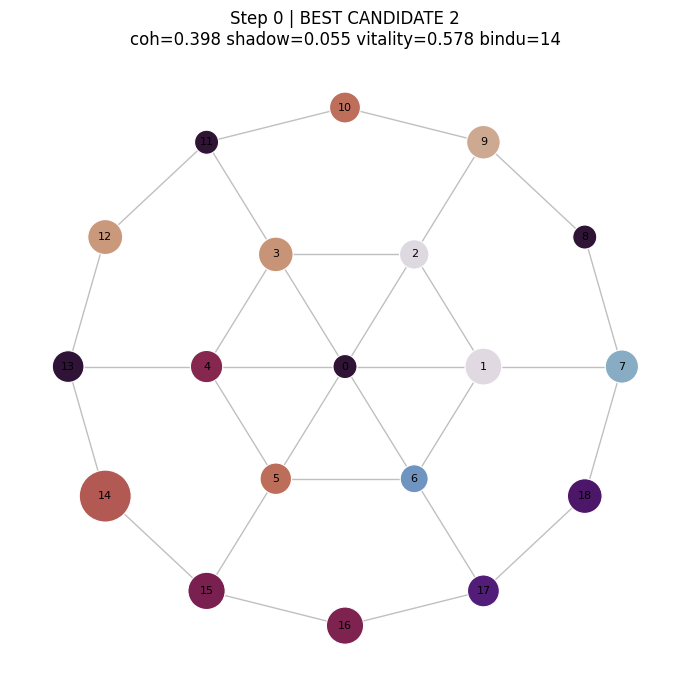

[STEP 1] best=9 coh=0.758 shadow=0.037 vitality=0.224 score=0.594 active=12 bindu=16
[STEP 2] best=9 coh=0.808 shadow=0.043 vitality=0.109 score=0.708 active=12 bindu=16
[STEP 3] best=9 coh=0.892 shadow=0.057 vitality=0.071 score=0.804 active=11 bindu=8
[STEP 4] best=9 coh=0.989 shadow=0.062 vitality=0.059 score=0.904 active=10 bindu=7
[STEP 5] best=9 coh=0.980 shadow=0.066 vitality=0.040 score=0.903 active=10 bindu=7


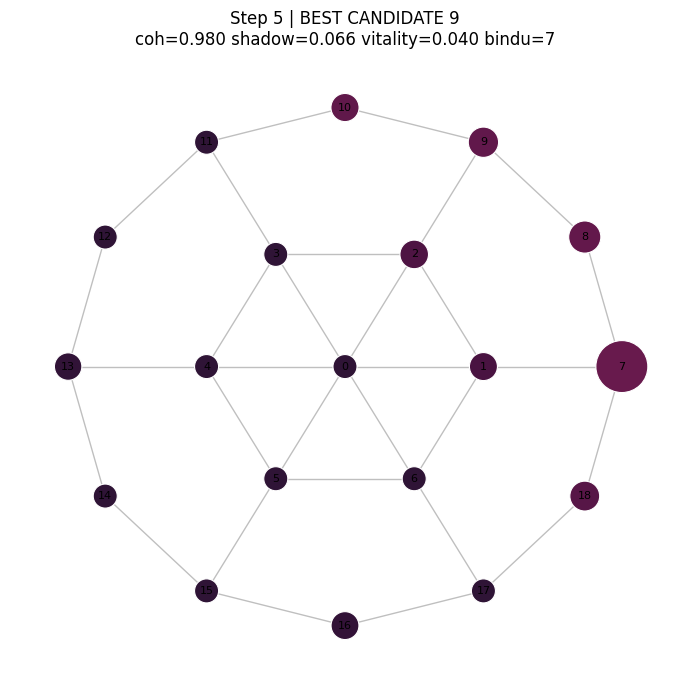

[STEP 6] best=9 coh=0.985 shadow=0.071 vitality=0.049 score=0.899 active=10 bindu=7
[STEP 7] best=2 coh=0.994 shadow=0.071 vitality=0.043 score=0.912 active=9 bindu=14
[STEP 8] best=10 coh=0.995 shadow=0.071 vitality=0.044 score=0.912 active=9 bindu=11
[STEP 9] best=10 coh=0.994 shadow=0.085 vitality=0.044 score=0.899 active=8 bindu=12
[STEP 10] best=10 coh=0.996 shadow=0.073 vitality=0.057 score=0.903 active=7 bindu=10


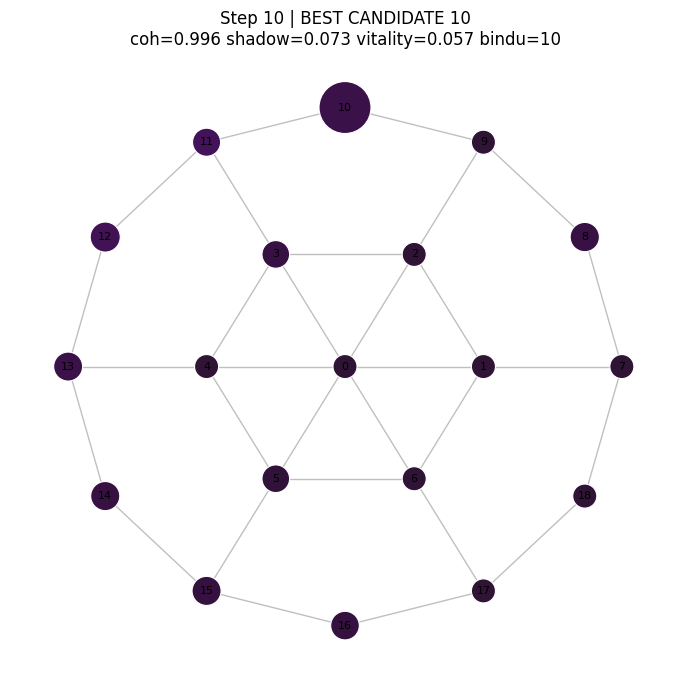

[STEP 11] best=2 coh=0.994 shadow=0.078 vitality=0.044 score=0.906 active=6 bindu=14
[STEP 12] best=2 coh=0.986 shadow=0.075 vitality=0.018 score=0.915 active=6 bindu=14
[STEP 13] best=2 coh=0.972 shadow=0.079 vitality=0.027 score=0.893 active=5 bindu=14
[STEP 14] best=11 coh=0.986 shadow=59595834311.883 vitality=0.070 score=-47676667448.562 active=2 bindu=10
[STEP 15] best=11 coh=0.984 shadow=48971094283.464 vitality=0.054 score=-39176875425.820 active=2 bindu=10


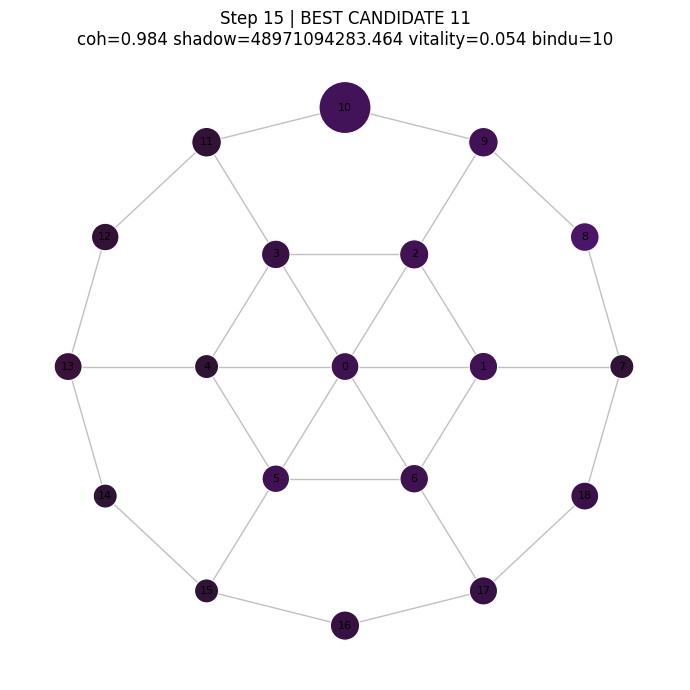

[STEP 16] best=6 coh=0.992 shadow=41132148059.712 vitality=0.074 score=-32905718446.822 active=2 bindu=8
[STEP 17] best=6 coh=0.988 shadow=0.075 vitality=0.043 score=0.902 active=2 bindu=18
[STEP 18] best=11 coh=0.990 shadow=47305285503.319 vitality=0.061 score=-37844228401.702 active=2 bindu=7
[STEP 19] best=11 coh=0.996 shadow=0.071 vitality=0.028 score=0.923 active=2 bindu=18
[STEP 20] best=11 coh=0.997 shadow=0.079 vitality=0.018 score=0.924 active=2 bindu=18


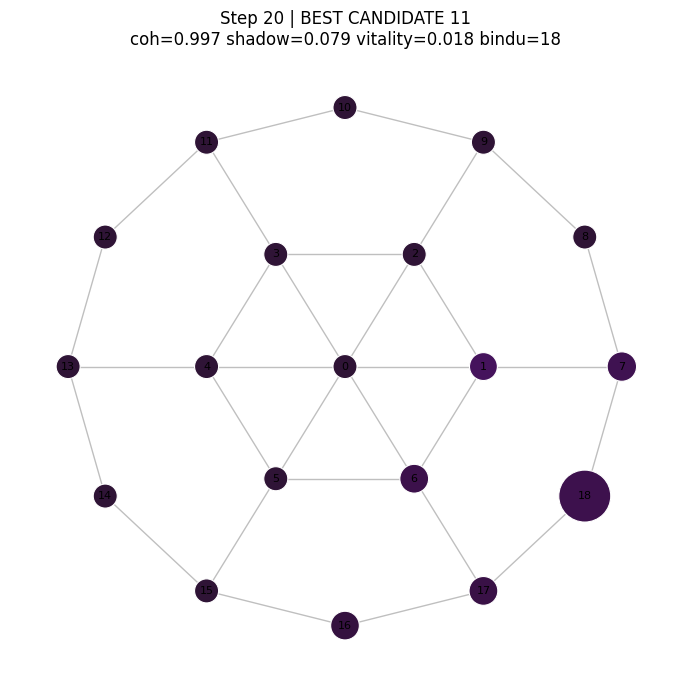

[STEP 21] best=11 coh=0.999 shadow=0.080 vitality=0.038 score=0.912 active=1 bindu=17
[STEP 22] best=11 coh=0.999 shadow=0.077 vitality=0.048 score=0.909 active=1 bindu=7
[STEP 23] best=11 coh=0.999 shadow=0.073 vitality=0.048 score=0.913 active=1 bindu=8
[STEP 24] best=11 coh=0.998 shadow=0.072 vitality=0.038 score=0.918 active=1 bindu=7
[STEP 25] best=11 coh=0.992 shadow=0.073 vitality=0.032 score=0.914 active=1 bindu=8


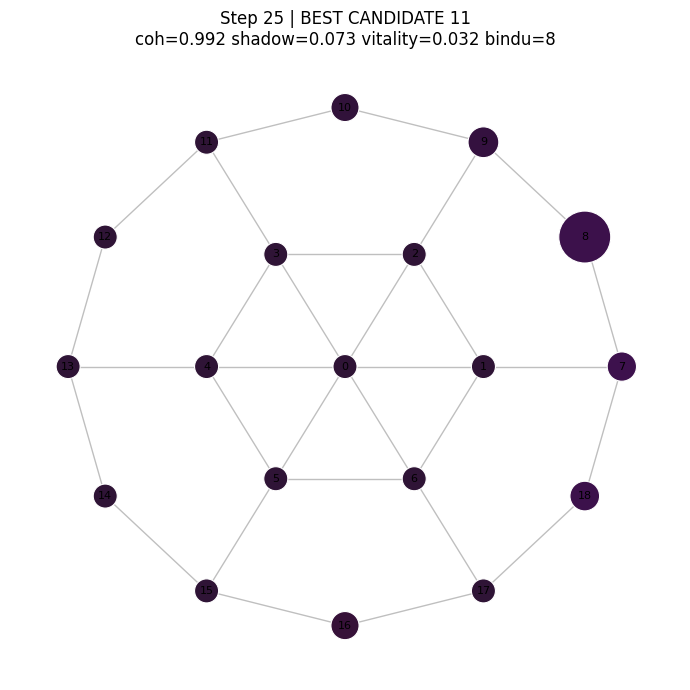

[STEP 26] best=11 coh=0.990 shadow=0.071 vitality=0.024 score=0.919 active=1 bindu=8
[STEP 27] best=11 coh=0.996 shadow=0.064 vitality=0.047 score=0.916 active=1 bindu=9
[STEP 28] best=11 coh=0.990 shadow=0.059 vitality=0.034 score=0.922 active=1 bindu=8
[STEP 29] best=11 coh=0.998 shadow=0.073 vitality=0.065 score=0.900 active=1 bindu=9


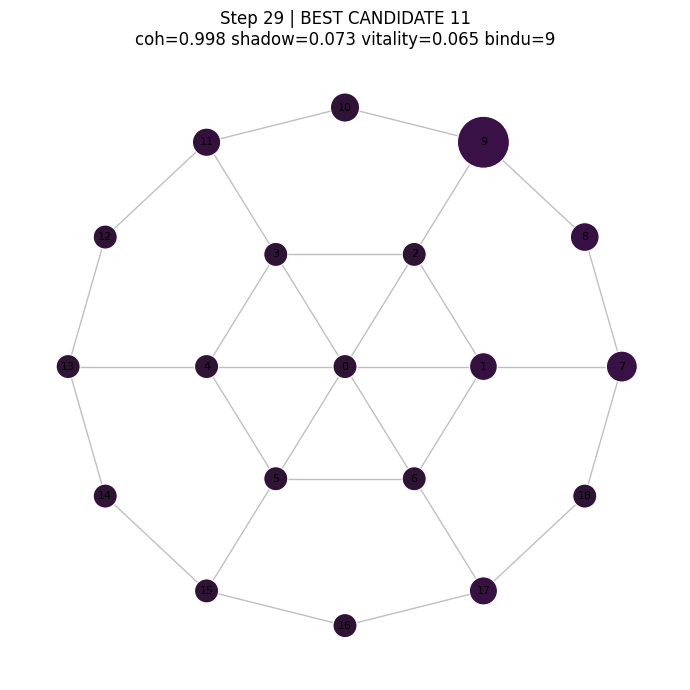

=== V-KERNEL LIVE SIMULATION END ===


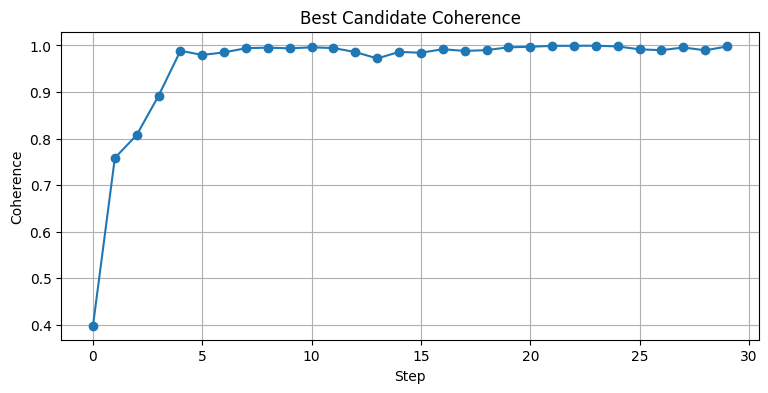

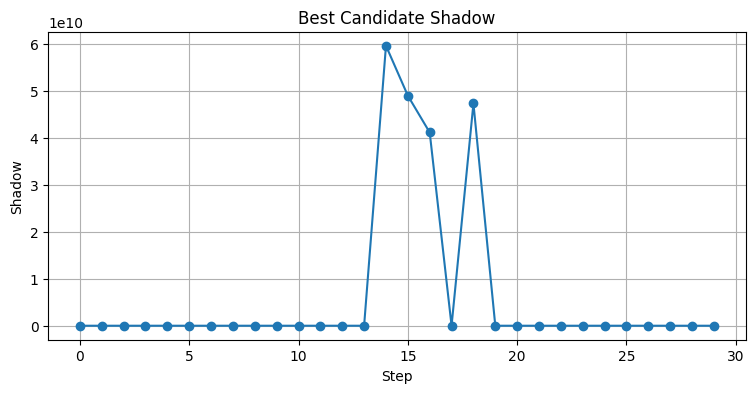

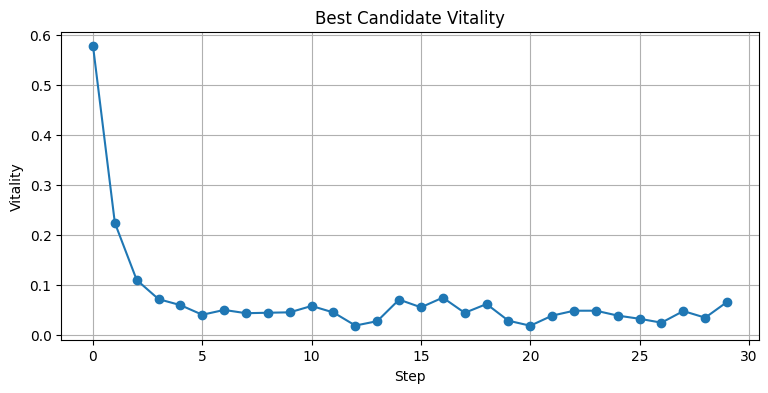

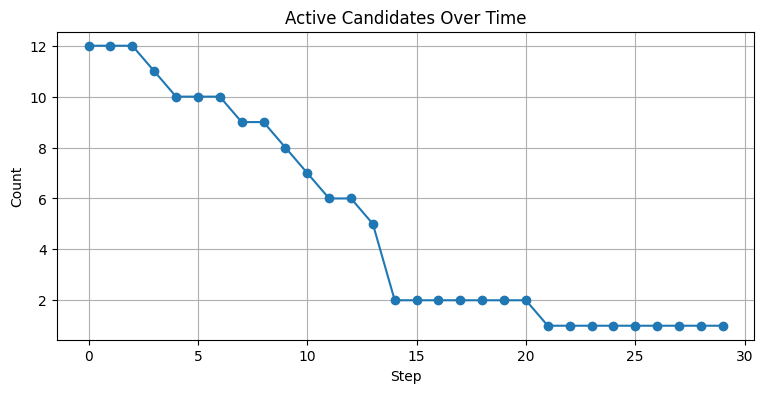

Save notebook as: simulation/vkernel_live_simulation.ipynb


In [7]:
# initialize candidates
candidates = []
for cid in range(NUM_CANDIDATES):
    amp = np.random.uniform(0.2, 1.0, size=len(G.nodes()))
    phase = np.random.uniform(0.0, 2 * np.pi, size=len(G.nodes()))
    z = amp * np.exp(1j * phase)
    candidates.append({"cid": cid, "z": z, "active": True})

history_coh = []
history_sh = []
history_vit = []
history_active = []

print("=== V-KERNEL LIVE SIMULATION START ===")

for step in range(STEPS):
    for c in candidates:
        if not c["active"]:
            continue

        prev = c["z"].copy()

        z = add_noise(c["z"], NOISE_LEVEL)
        z = wave_update(W, z)
        z = prune(z, PRUNE_THRESHOLD)

        radial = radial_projection(G, z)
        ring = ring_projection(G, z)
        node = node_projection(G, z)
        encoded = encode_state(radial, ring, node, z)

        coh = coherence(z)
        sh = shadow(encoded)
        vit = vitality(prev, z)
        sc = score_fn(coh, sh, vit)

        c["z"] = z
        c["coh"] = coh
        c["shadow"] = sh
        c["vitality"] = vit
        c["score"] = sc

        if np.sum(np.abs(z)) < 0.8:
            c["active"] = False

    active_candidates = [c for c in candidates if c["active"]]
    if not active_candidates:
        print(f"[STEP {step}] no active candidates remain")
        break

    best = max(active_candidates, key=lambda x: x["score"])

    history_coh.append(best["coh"])
    history_sh.append(best["shadow"])
    history_vit.append(best["vitality"])
    history_active.append(len(active_candidates))

    print(
        f"[STEP {step}] "
        f"best={best['cid']} "
        f"coh={best['coh']:.3f} "
        f"shadow={best['shadow']:.3f} "
        f"vitality={best['vitality']:.3f} "
        f"score={best['score']:.3f} "
        f"active={len(active_candidates)} "
        f"bindu={detect_bindu(best['z'])}"
    )

    if step % SHOW_EVERY == 0 or step == STEPS - 1:
        plot_candidate_graph(
            G,
            best["z"],
            best["coh"],
            best["shadow"],
            best["vitality"],
            step,
            label=f"BEST CANDIDATE {best['cid']}"
        )

print("=== V-KERNEL LIVE SIMULATION END ===")

plt.figure(figsize=(9, 4))
plt.plot(history_coh, marker="o")
plt.title("Best Candidate Coherence")
plt.xlabel("Step")
plt.ylabel("Coherence")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(history_sh, marker="o")
plt.title("Best Candidate Shadow")
plt.xlabel("Step")
plt.ylabel("Shadow")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(history_vit, marker="o")
plt.title("Best Candidate Vitality")
plt.xlabel("Step")
plt.ylabel("Vitality")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(history_active, marker="o")
plt.title("Active Candidates Over Time")
plt.xlabel("Step")
plt.ylabel("Count")
plt.grid(True)
plt.show()

print("Save notebook as: simulation/vkernel_live_simulation.ipynb")